    model_name model_type uniprot_type pose_source       mean       std
0   DecompDiff     denovo          all         raw  21.950672  0.115194
1   DecompDiff     denovo          all        vina   8.452138  0.352078
2   DecompDiff     denovo         seen         raw  22.760012  0.100542
3   DecompDiff     denovo         seen        vina   8.516106  0.517299
4   DecompDiff     denovo       unseen         raw  19.698665  0.160278
5   DecompDiff     denovo       unseen        vina   8.269419  0.169879
6       Delete   hit2lead          all         raw   6.248797  0.113265
7       Delete   hit2lead          all        vina   8.263933  0.091565
8       Delete   hit2lead         seen         raw   6.463862  0.104506
9       Delete   hit2lead         seen        vina   7.842501  0.108332
10      Delete   hit2lead       unseen         raw   5.726783  0.135570
11      Delete   hit2lead       unseen        vina   9.287360  0.223828
12     DiffDec   hit2lead          all         raw   5.526969  0

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


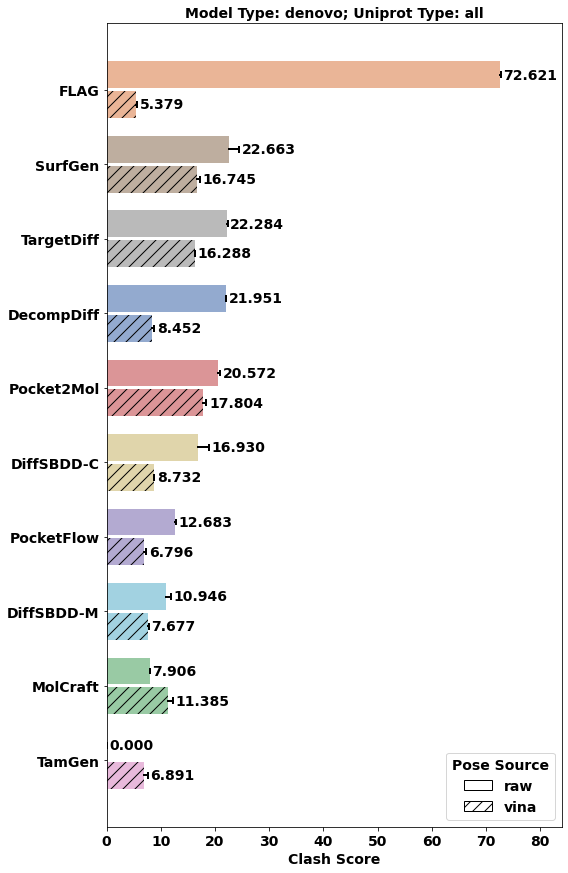

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


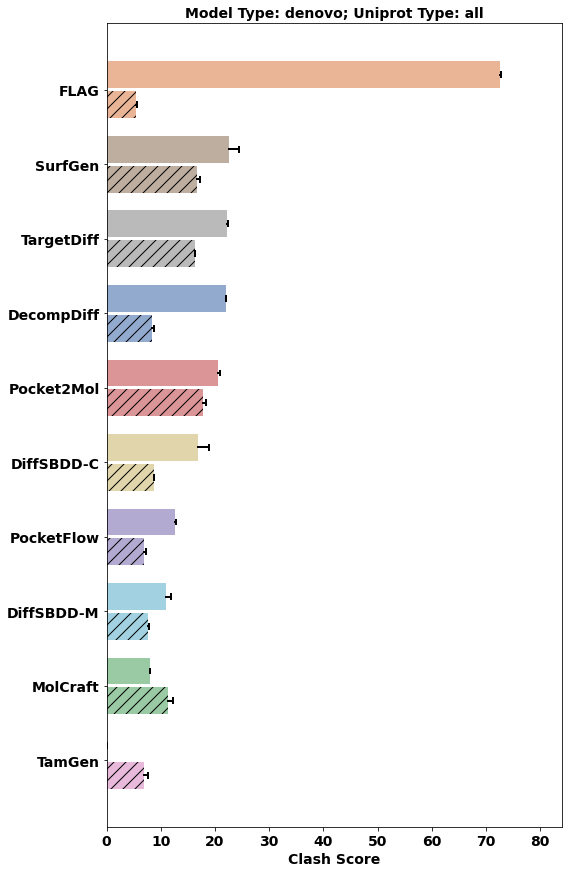

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


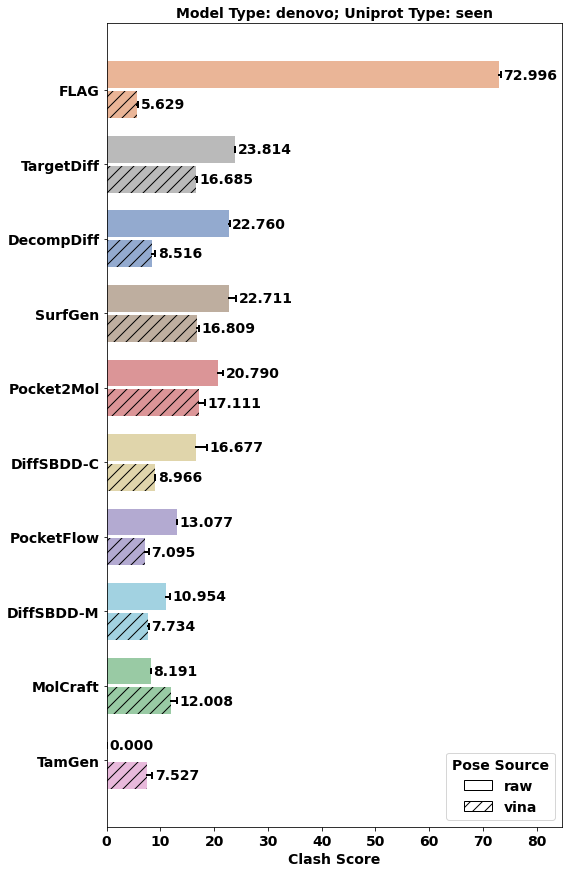

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


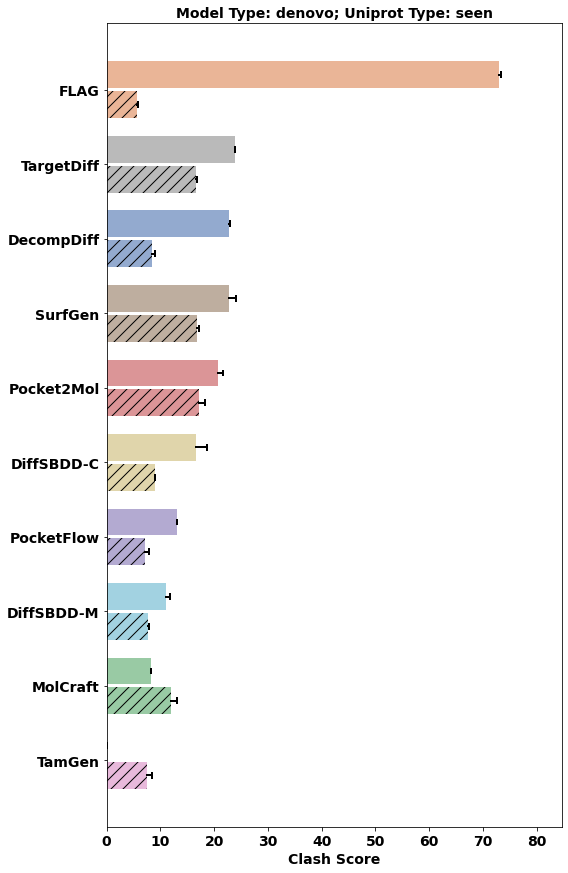

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


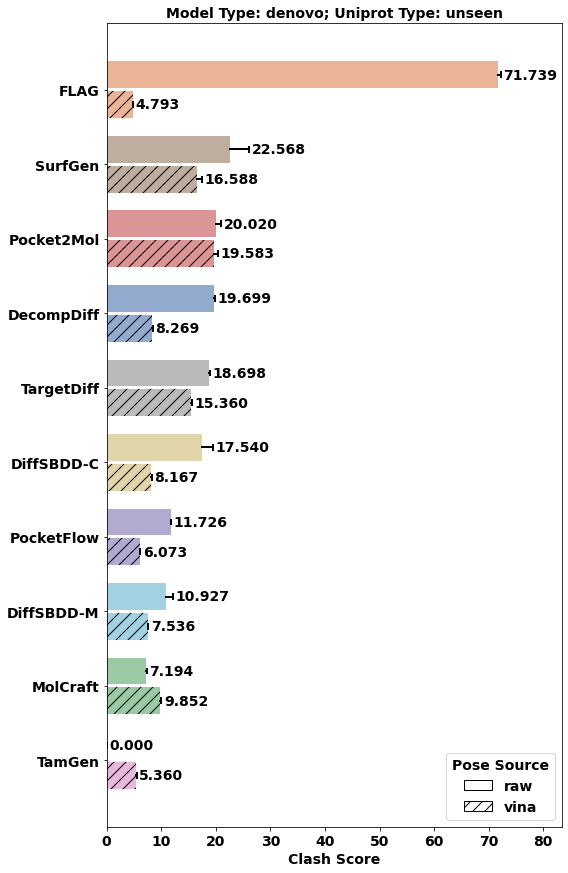

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


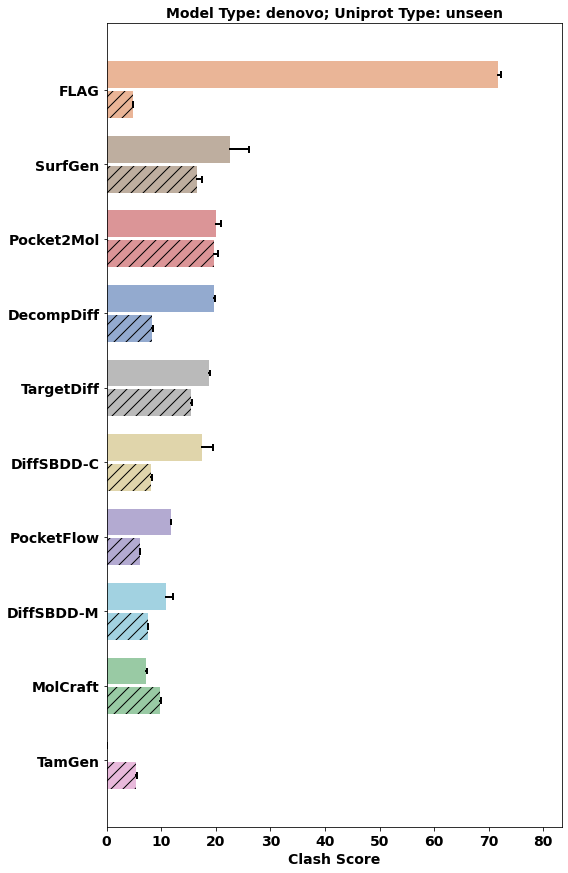

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


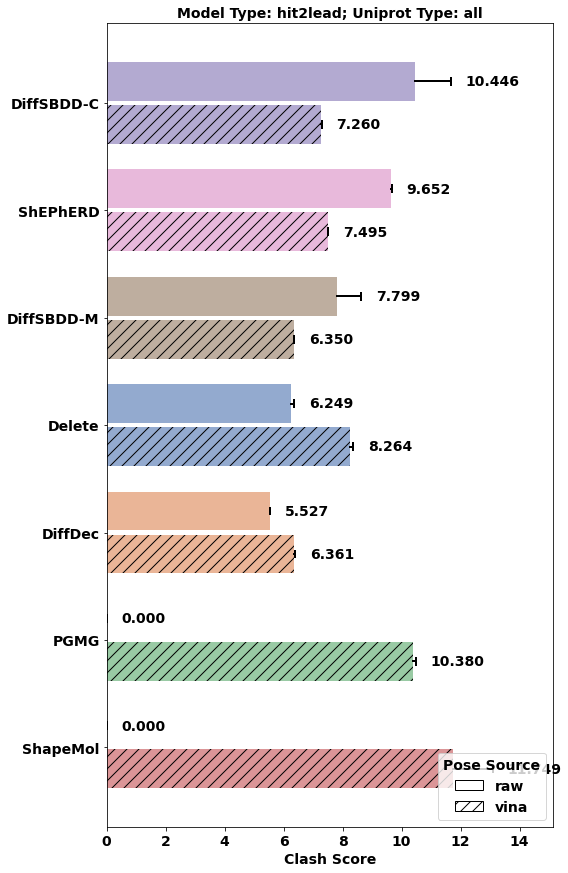

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


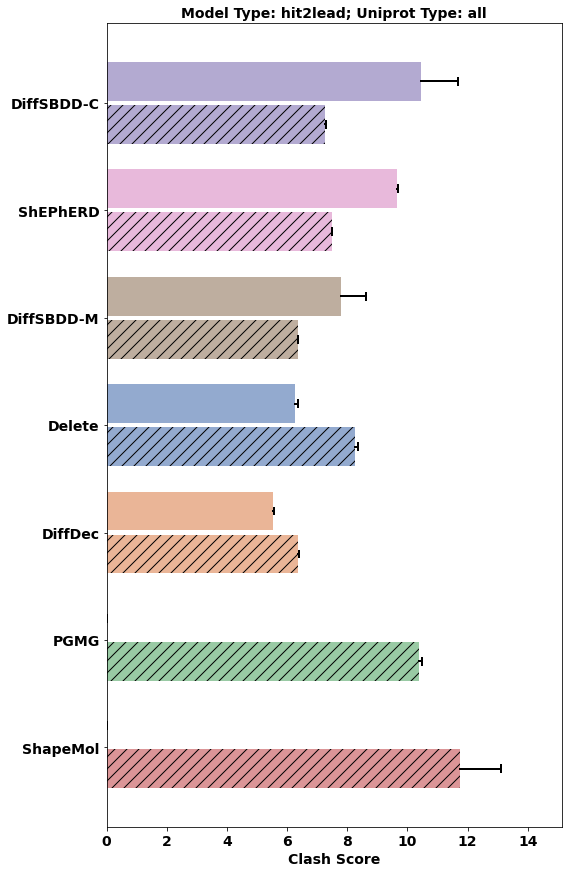

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


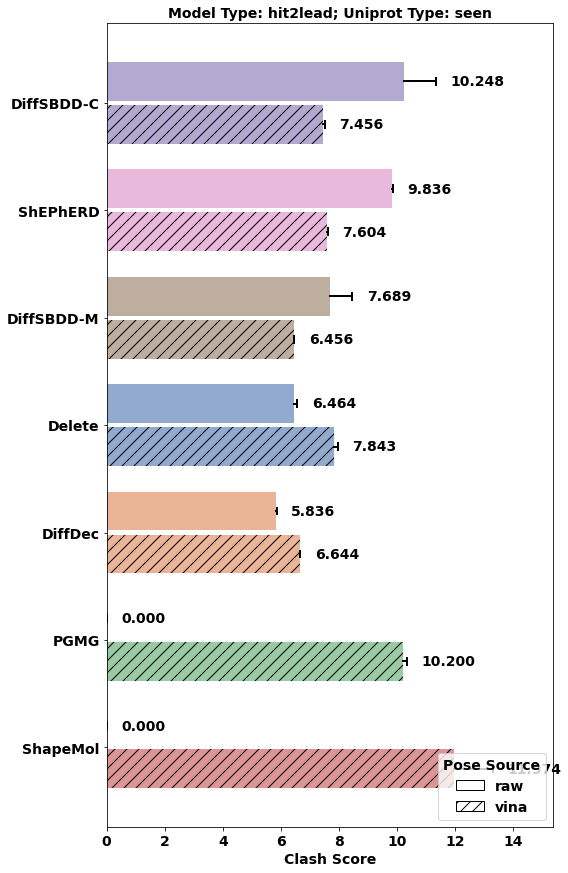

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


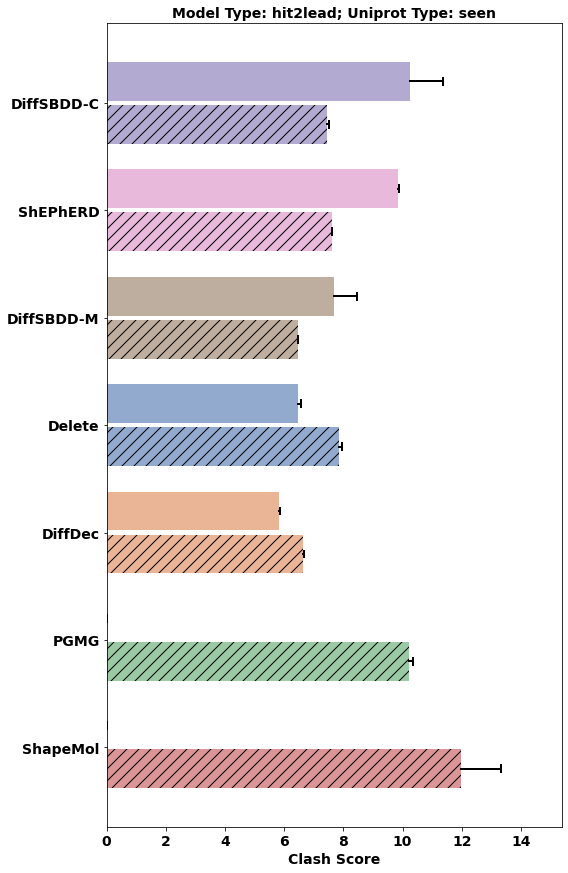

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


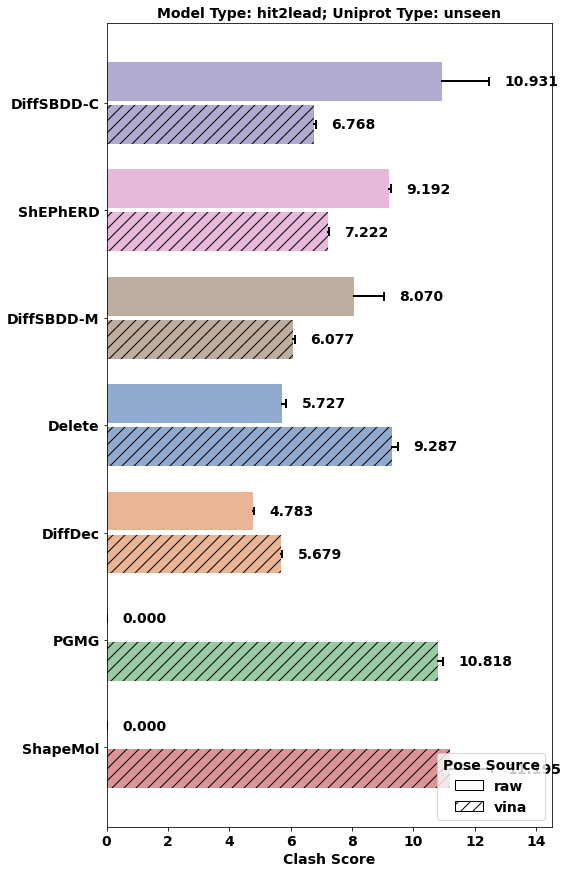

/tmp/ipykernel_4101074/2776948930.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


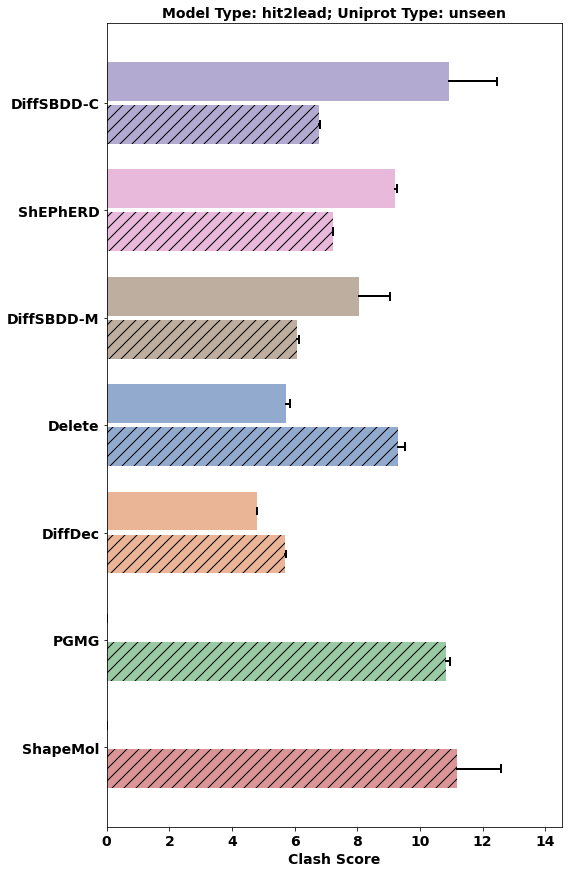

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_fig_dir = "../final_plot/output/clash"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]

TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "diffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "diffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "diffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "diffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "shepherd",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}


# ========== 读取数据 ==========
results_list = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "denovo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "hit2lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)
                
                def get_clash_score(result, metric_key, split):
                    try:
                        return result['metrics'][metric_key][split]['ClashScore']
                    except (KeyError, TypeError):
                        return 0.0

                # 分别存储 all/seen/unseen 和 raw/vina
                for uniprot_type in ['all', 'seen', 'unseen']:
                    # raw pose
                    results_list.append({
                        "model_name": name_mapping[task],
                        "Round": round_name,
                        "model_type": task_type,
                        "uniprot_type": uniprot_type,
                        "pose_source": "raw",
                        "ClashScore": get_clash_score(result, 'ClashScore', uniprot_type),
                    })
                    
                    # vina pose
                    results_list.append({
                        "model_name": name_mapping[task],
                        "Round": round_name,
                        "model_type": task_type,
                        "uniprot_type": uniprot_type,
                        "pose_source": "vina",
                        "ClashScore": get_clash_score(result, 'ClashScore_docked', uniprot_type),
                    })

df_results = pd.DataFrame(results_list)


# ========== 聚合数据：计算 mean 和 std ==========
df_agg = (
    df_results
    .groupby(['model_name', 'model_type', 'uniprot_type', 'pose_source'])['ClashScore']
    .agg(['mean', 'std'])
    .reset_index()
)

# 填充 NaN（如果只有一个 Round，std 会是 NaN）
df_agg['std'] = df_agg['std'].fillna(0)

print(df_agg.head(20))


# ========== 绘图函数 ==========
def replace_model_name(model_name):
    if 'diffSBDD-C' in model_name:
        return 'DiffSBDD-C'
    elif 'diffSBDD-M' in model_name:
        return 'DiffSBDD-M'
    elif 'shepherd' in model_name:
        return 'ShEPhERD'
    elif 'Delete' in model_name:
        return 'Delete'
    else:
        return model_name


def plot_clash_score_boxh(df, model_type='hit2lead', uniprot_type='all', plot_type='without_mean_value'):
    """
    绘制 ClashScore 水平柱状图
    
    Parameters:
    -----------
    df : DataFrame
        聚合后的数据，包含 model_name, model_type, uniprot_type, pose_source, mean, std
    model_type : str
        'denovo' 或 'hit2lead'
    uniprot_type : str
        'all', 'seen', 或 'unseen'
    plot_type : str
        'with_mean_value' 或 'without_mean_value'
    """
    # 筛选数据
    combined_df_temp = df[(df['model_type'] == model_type) & (df['uniprot_type'] == uniprot_type)]
    
    if combined_df_temp.empty:
        print(f"Warning: No data for model_type={model_type}, uniprot_type={uniprot_type}")
        return
    
    title_str = f"Model Type: {model_type}; Uniprot Type: {uniprot_type}"
    
    pose_source_order = ['raw', 'vina']
    hatches = ['', '//']

    # 1. 按 raw 值排序模型（用于显示顺序）
    raw_means = combined_df_temp[
        combined_df_temp['pose_source'] == 'raw'
    ].set_index('model_name')['mean'].sort_values(ascending=False)
    sorted_model_names = raw_means.index.tolist()

    # 2. 定义颜色映射（按模型名字字母排序分配颜色，保证不同图中相同模型颜色一致）
    model_names = list(combined_df_temp['model_name'].unique())
    model_names = sorted(model_names)  # 按字母排序
    color_list = sns.color_palette("deep", len(model_names))
    color_map = {name: color_list[i] for i, name in enumerate(model_names)}

    # 3. 创建图形（固定大小 8x12）
    plt.figure(figsize=(8, 12))
    
    n_models = len(sorted_model_names)
    
    ax = sns.barplot(
        y='model_name', x='mean',
        data=combined_df_temp[combined_df_temp['pose_source'] == 'raw'],
        order=sorted_model_names,
        palette=color_map,
        edgecolor='white',
        linewidth=1,
        alpha=0
    )

    # 计算每个模型的位置和宽度
    bar_width = 0.8 / len(pose_source_order)

    for model_idx, model in enumerate(sorted_model_names):
        model_y = model_idx
        base_color = color_map[model]
        
        for pose_idx, pose in enumerate(pose_source_order):
            pose_y = model_y - 0.4 + (pose_idx + 0.5) * bar_width
            
            data = combined_df_temp[
                (combined_df_temp['model_name'] == model) & 
                (combined_df_temp['pose_source'] == pose)
            ]
            
            if not data.empty:
                mean_val = data['mean'].values[0]
                std_val = data['std'].values[0]
                
                # 绘制条形
                ax.barh(
                    pose_y, mean_val,
                    height=bar_width * 0.9,
                    color=base_color,
                    linewidth=1,
                    alpha=0.6,
                    hatch=hatches[pose_idx]
                )
                
                # 添加误差条
                if not np.isnan(std_val):
                    # 横线：从均值到均值+std
                    ax.plot(
                        [mean_val, mean_val + std_val],
                        [pose_y, pose_y],
                        color='black',
                        linewidth=2
                    )
                    # 竖线（误差棒末端）
                    ax.plot(
                        [mean_val + std_val, mean_val + std_val],
                        [pose_y - 0.08 * bar_width, pose_y + 0.08 * bar_width],
                        color='black',
                        linewidth=2
                    )
                
                # 添加数值标签
                if plot_type == 'with_mean_value':
                    ax.text(
                        mean_val + std_val + 0.5,
                        pose_y,
                        f"{mean_val:.3f}",
                        va='center',
                        ha='left',
                        fontsize=14,
                        fontweight='bold'
                    )

    # 5. 设置 y 轴刻度
    ax.set_yticks(range(n_models))
    ax.set_yticklabels([replace_model_name(x) for x in sorted_model_names])

    # 6. 创建自定义图例
    hatch_legend = [
        Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=pose_name)
        for i, pose_name in enumerate(pose_source_order)
    ]
    
    if plot_type == 'with_mean_value':
        legend = plt.legend(
            handles=hatch_legend,
            title='Pose Source',
            loc='lower right',
            fontsize=14,
            title_fontsize=14,
            frameon=True
        )
        legend.get_title().set_fontweight('bold')
        for txt in legend.get_texts():
            txt.set_fontweight('bold')

    # 7. 标签和样式
    plt.ylabel('')
    plt.xlabel('Clash Score', fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')

    # 设置 x 轴范围，为数值标签留出空间
    xlim = ax.get_xlim()
    ax.set_xlim(xlim[0], xlim[1] * 1.1)

    plt.tight_layout()
    plt.title(title_str, fontsize=14, fontweight='bold')
    
    os.makedirs(save_fig_dir, exist_ok=True)
    plt.savefig(
        f'{save_fig_dir}/10-clash_score_boxh_{model_type}_{uniprot_type}_{plot_type}.svg',
        bbox_inches='tight', dpi=660, format='svg'
    )
    plt.show()
    plt.close()


# ========== 调用绑图 ==========
# De novo
for uniprot_type in ['all', 'seen', 'unseen']:
    for plot_type in ['with_mean_value', 'without_mean_value']:
        plot_clash_score_boxh(df_agg, model_type='denovo', uniprot_type=uniprot_type, plot_type=plot_type)

# Hit to Lead
for uniprot_type in ['all', 'seen', 'unseen']:
    for plot_type in ['with_mean_value', 'without_mean_value']:
        plot_clash_score_boxh(df_agg, model_type='hit2lead', uniprot_type=uniprot_type, plot_type=plot_type)